Unique values in 'sentiment': [3.20894318 2.245883   2.5091372  2.86432218 1.89230498 1.97289466
 2.85275333 1.83493536 1.97480161 1.72117282 3.29043786 1.68841642
 2.33024976 2.41866416 4.14295728 2.80891703 1.38619579 1.37776712
 1.64524983 1.34869863 2.01115924 2.79762178 2.01875    2.7602665
 1.64676171 2.39445305 1.62364874 2.35589108 2.26192517 2.32097614
 1.4419243  2.62106447 3.537711   1.76349671 1.80923355 2.33736251
 2.72133378 2.21071222 1.96860461 2.78691043 2.87083545 0.81074132
 3.10743708 2.86239447 2.22085947 2.68652556 2.77192785 2.11803788
 3.34305105 1.87044299 1.71889023 1.74684573 2.66436528 3.16416029
 2.87656332 3.13709162 2.83147901 2.93217716 2.70336581 2.12726667
 1.7353747  2.91748921 2.11068997 2.88200197 1.37146725]
Naive Bayes Accuracy: 0.79
Random Forest Accuracy: 0.86
SVM Accuracy: 0.79


D:\Anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Random Forest - Accuracy: 0.86, Precision: 0.75, Recall: 0.75, F1-Score: 0.75
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.75      0.75      0.75         4

    accuracy                           0.86        14
   macro avg       0.82      0.82      0.82        14
weighted avg       0.86      0.86      0.86        14

Confusion Matrix:
[[9 1]
 [1 3]]

AdaBoost - Accuracy: 0.79, Precision: 0.67, Recall: 0.50, F1-Score: 0.57
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.67      0.50      0.57         4

    accuracy                           0.79        14
   macro avg       0.74      0.70      0.71        14
weighted avg       0.77      0.79      0.78        14

Confusion Matrix:
[[9 1]
 [2 2]]

Stacking - Accuracy: 0.86, Precision: 1.00, Recall: 0.50, F1-Score: 0.67
Classif

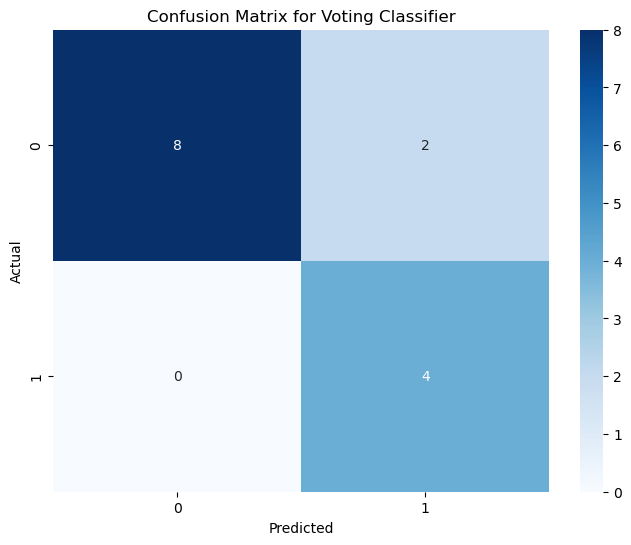

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
data = pd.read_csv('Abnb_paris.csv')  

# Step 2: Data Preprocessing
# Drop unnecessary columns
data = data.drop(columns=['logreviews', 'logsavwish'])

# Check unique values in 'sentiment' to understand the data
print("Unique values in 'sentiment':", data['sentiment'].unique())

# Step 3: Define Mapping Strategy
# Any value greater than or equal to 2.5 is 'positive', and less than 2.5 is 'negative'
data['sentiment'] = data['sentiment'].apply(lambda x: 1 if x >= 2.5 else 0)

# Check for NaN in 'sentiment'
assert not data['sentiment'].isnull().any(), "There are NaN values in 'sentiment'"

# Step 4: Train-Test Split
X = data['review_text']
y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature Extraction
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Step 6: Build Base Models
base_models = {
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(kernel='linear', probability=True)
}

# Step 7: Train Base Models
for name, model in base_models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.2f}")

# Step 8: Ensemble Models
# Random Forest (Bagging)
rf_model = RandomForestClassifier()
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)

# AdaBoost (Boosting)
ada_model = AdaBoostClassifier()
ada_model.fit(X_train_tfidf, y_train)
ada_pred = ada_model.predict(X_test_tfidf)

# Stacking (Ensemble)
stacked_model = StackingClassifier(
    estimators=[('nb', MultinomialNB()), ('rf', RandomForestClassifier()), ('svm', SVC(kernel='linear', probability=True))],
    final_estimator=LogisticRegression()
)
stacked_model.fit(X_train_tfidf, y_train)
stacked_pred = stacked_model.predict(X_test_tfidf)

# Voting Classifier
voting_model = VotingClassifier(
    estimators=[('nb', MultinomialNB()), ('rf', RandomForestClassifier()), ('svm', SVC(kernel='linear', probability=True))],
    voting='soft'
)
voting_model.fit(X_train_tfidf, y_train)
voting_pred = voting_model.predict(X_test_tfidf)

# Step 9: Model Evaluation
ensemble_models = {
    "Random Forest": rf_pred,
    "AdaBoost": ada_pred,
    "Stacking": stacked_pred,
    "Voting Classifier": voting_pred
}

for name, prediction in ensemble_models.items():
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    print(f"\n{name} - Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")
    print(f"Classification Report:\n{classification_report(y_test, prediction)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, prediction)}")

# Step 10: Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, voting_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Voting Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


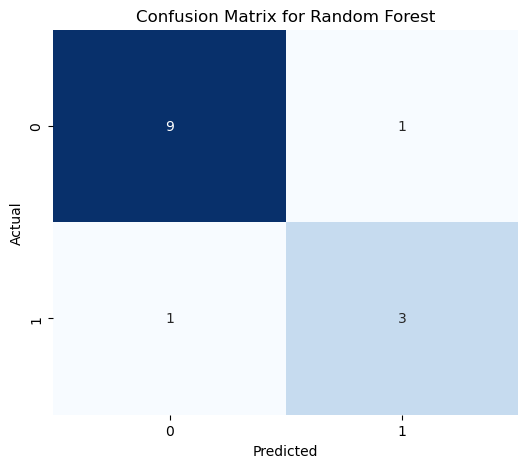

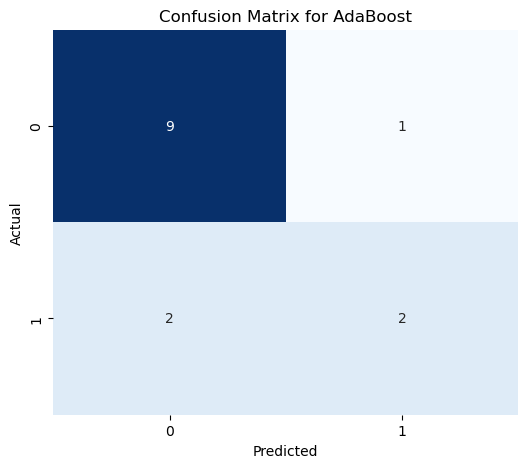

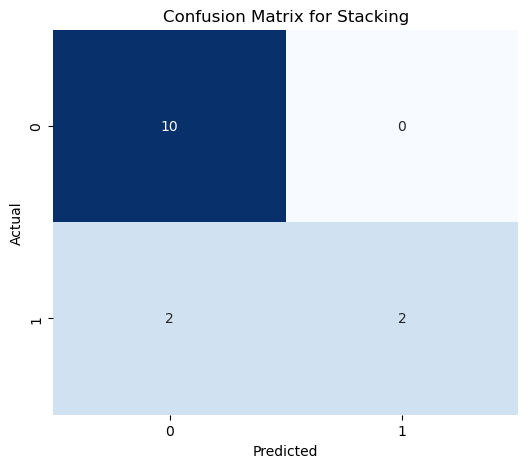

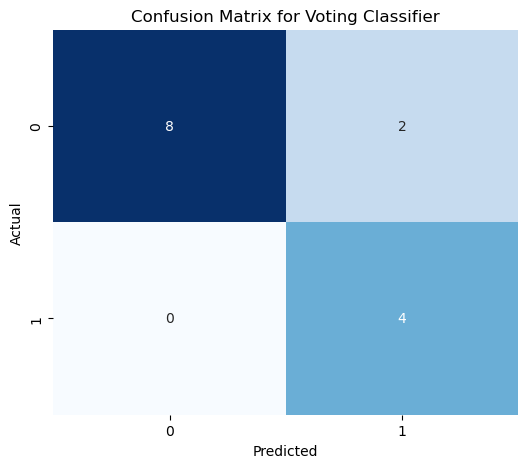

In [11]:
# Visualize confusion matrices for individual models
for name, prediction in ensemble_models.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, prediction), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [13]:
# Include all models in a single dictionary
all_models = {
    "Naive Bayes": base_models["Naive Bayes"],  # Base model
    "Random Forest": rf_model,  # Ensemble
    "SVM": base_models["SVM"],  # Base model
    "AdaBoost": ada_model,  # Ensemble
    "Stacking": stacked_model,  # Ensemble
    "Voting Classifier": voting_model  # Ensemble
}


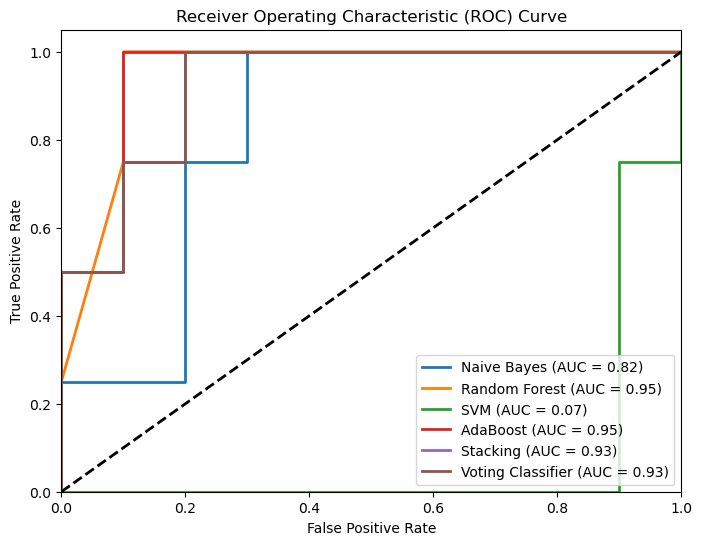

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Create ROC curves for all models
plt.figure(figsize=(8, 6))
for name, model in all_models.items():
    prob = model.predict_proba(X_test_tfidf)[:, 1]  # Get probabilities for positive class
    fpr, tpr, thresholds = roc_curve(y_test, prob)  # Compute ROC
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
